# 05 — Deep Learning Extension
**Member C — DL Lead**

Two DL components on the cleaned features from notebook 03:
1. **MLP** churn classifier (PyTorch, SMOTE + early stopping) vs best classical model.
2. **Autoencoder** for anomalous-customer detection (reconstruction error).

Plus **SHAP** explanations on the best tree model (and optionally on the MLP) to make the churn drivers interpretable.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import seed_all, savefig, DATA_PROCESSED, MODELS_DIR, REPORTS_DIR
from src.plot_style import apply_style, PALETTE
from src import classification as cls

seed_all(); apply_style()

In [2]:
splits = joblib.load(DATA_PROCESSED / 'splits.joblib')
# Transformed (scaled + one-hot) matrices for the MLP — same split as the classical models.
X_tr, y_tr = splits['X_train_t'], splits['y_train']
X_te, y_te = splits['X_test_t'],  splits['y_test']
# Raw frames + fitted preprocessor are kept for SHAP further down.
X_te_raw = splits['X_test_raw']
preprocessor = splits['preprocessor']
feat_names = splits['transformed_feature_names']
print(f'Train: {X_tr.shape}  Test: {X_te.shape}  |  features: {feat_names}')

Train: (4199, 10)  Test: (1050, 10)  |  features: ['Frequency', 'Monetary', 'avg_basket_value', 'avg_basket_size', 'unique_products', 'Recency', 'DominantCountry_France', 'DominantCountry_Germany', 'DominantCountry_United Kingdom', 'DominantCountry_infrequent_sklearn']


## 1. MLP — train with SMOTE + early stopping

In [3]:
mlp, train_losses, val_aucs, scaler_mlp = cls.train_mlp(X_tr, y_tr, X_te, y_te,
                                                        epochs=60, patience=8)
out = cls.mlp_evaluate(mlp, scaler_mlp, X_te, y_te)
print('MLP test metrics:'); print({k: round(v,4) for k,v in out['metrics'].items()})

INFO | early stopping at epoch 19 (best val AUC=0.7832)


MLP test metrics:
{'AUC': 0.7832, 'F1': 0.7381, 'Precision': 0.7561, 'Recall': 0.7209, 'Accuracy': 0.7067}


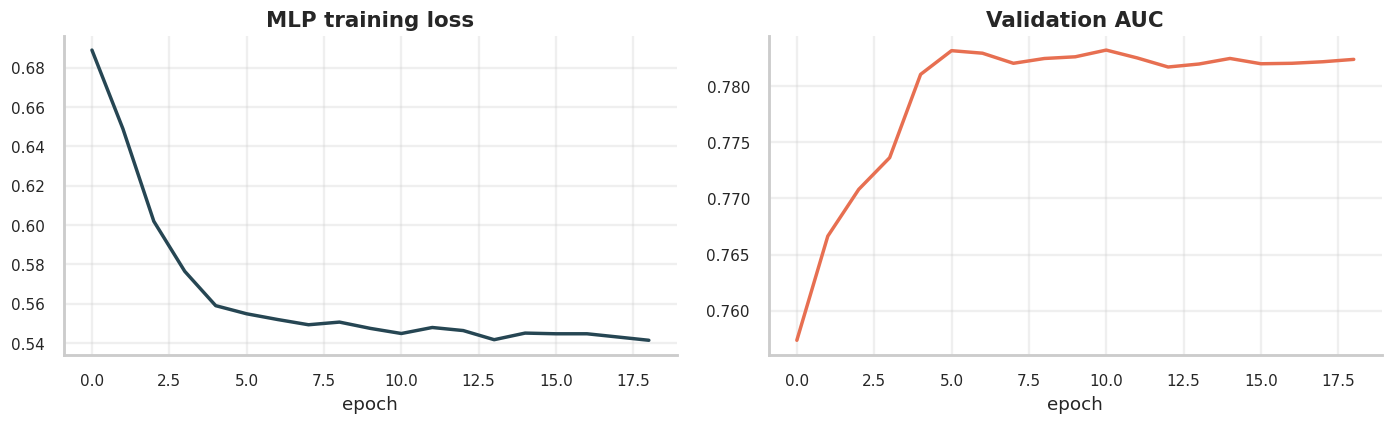

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(train_losses, color=PALETTE[0]); axes[0].set_title('MLP training loss'); axes[0].set_xlabel('epoch')
axes[1].plot(val_aucs, color=PALETTE[4]); axes[1].set_title('Validation AUC'); axes[1].set_xlabel('epoch')
fig.tight_layout(); savefig(fig, '05_mlp_curves'); plt.show()

## 2. Compare MLP vs best classical

In [5]:
classical = pd.read_csv(REPORTS_DIR / 'classical_results.csv').sort_values('AUC', ascending=False)
best_row = classical.iloc[0]
compare = pd.DataFrame([
    {'Model': f"Best classical ({best_row['Model']})", **{k: best_row[k] for k in ['AUC','F1','Precision','Recall','Accuracy']}},
    {'Model': 'MLP (PyTorch)',                          **{k: round(out['metrics'][k],4) for k in ['AUC','F1','Precision','Recall','Accuracy']}},
])
compare.to_csv(REPORTS_DIR / 'mlp_vs_classical.csv', index=False)
compare

,Model,AUC,F1,Precision,Recall,Accuracy
0,Best classical (LogisticRegression),0.7850,0.7392,0.7698,0.7110,0.7124
1,MLP (PyTorch),0.7832,0.7381,0.7561,0.7209,0.7067


## 3. Autoencoder — anomalous customer detection

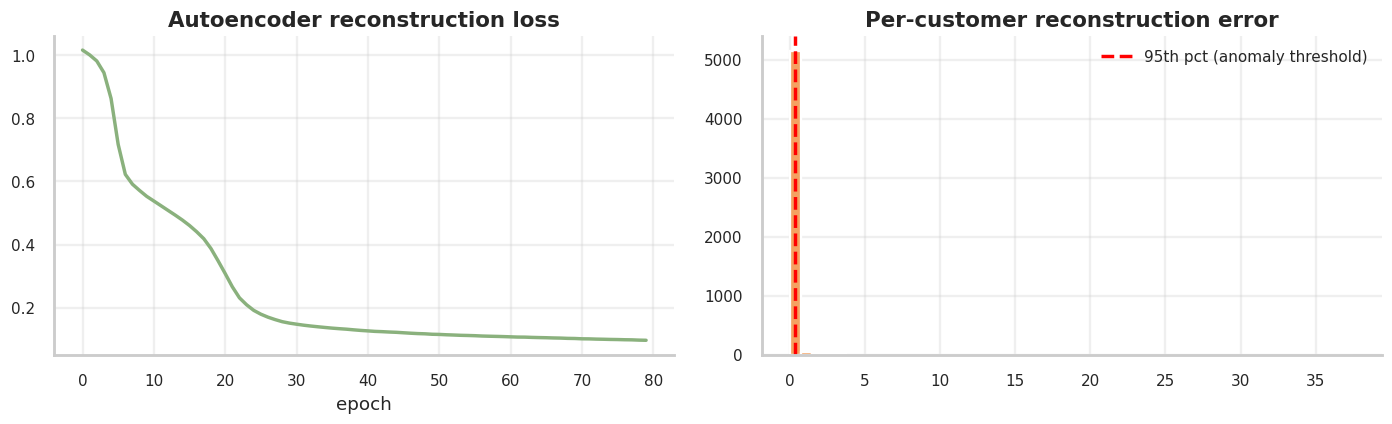

In [6]:
from src.features import NUMERIC_FEATURES
# Train the autoencoder on the leakage-safe pre-cutoff features (keeps CustomerID
# so anomalies map straight back to customers).
ae_feats = pd.read_csv(DATA_PROCESSED / 'classification_features.csv')
X_ae = ae_feats[NUMERIC_FEATURES]
ae, ae_losses, ae_scaler, recon_err = cls.train_autoencoder(X_ae, epochs=80)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(ae_losses, color=PALETTE[5]); axes[0].set_title('Autoencoder reconstruction loss'); axes[0].set_xlabel('epoch')
axes[1].hist(recon_err, bins=50, color=PALETTE[3], edgecolor='white')
axes[1].axvline(np.percentile(recon_err, 95), color='red', ls='--', label='95th pct (anomaly threshold)')
axes[1].set_title('Per-customer reconstruction error'); axes[1].legend()
fig.tight_layout(); savefig(fig, '05_autoencoder'); plt.show()

In [7]:
# Flag the top-5% customers by reconstruction error (leakage-safe features).
thresh = np.percentile(recon_err, 95)
ae_feats = ae_feats.assign(recon_err=recon_err)
anomalies = (ae_feats[ae_feats['recon_err'] >= thresh]
             .sort_values('recon_err', ascending=False)
             .reset_index(drop=True))
print(f'Flagged {len(anomalies):,} anomalous customers ({len(anomalies)/len(ae_feats):.1%})')
anomalies[['CustomerID','Recency','Frequency','Monetary','DominantCountry','recon_err']].head(10)

Flagged 263 anomalous customers (5.0%)


,CustomerID,Recency,Frequency,Monetary,DominantCountry,recon_err
0,13687,338,1,1683.60,United Kingdom,37.513577
1,17850,272,155,55892.88,United Kingdom,12.508415
2,12357,288,2,11244.94,Switzerland,6.691942
3,17949,0,102,43080.85,United Kingdom,6.357819
4,18102,26,111,261501.66,United Kingdom,5.929006
5,15061,27,116,102850.78,United Kingdom,5.881397
6,14298,23,74,74042.48,United Kingdom,5.228336
7,16029,7,90,61163.32,United Kingdom,4.617663
8,16422,7,96,49144.73,United Kingdom,4.409937
9,17841,3,165,50264.96,United Kingdom,4.383836


## 4. SHAP — interpret the best tree model

D:\Data mining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


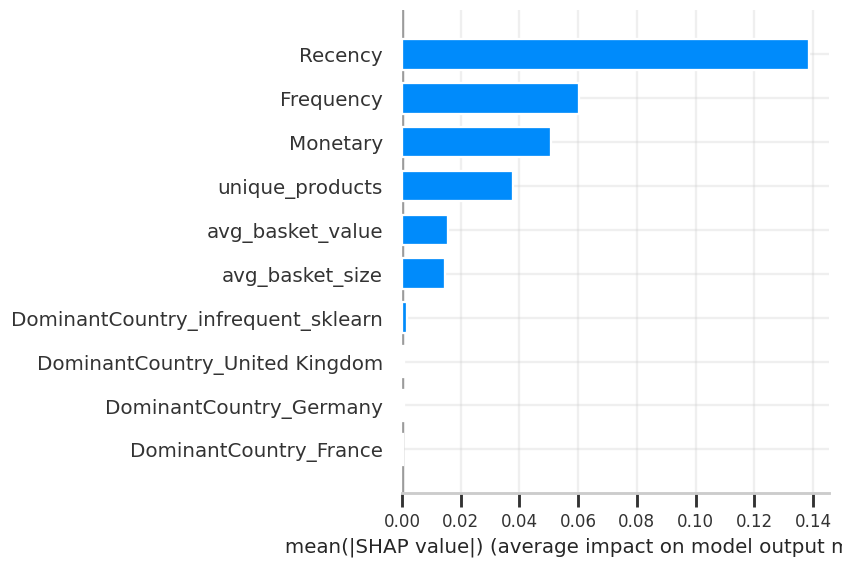

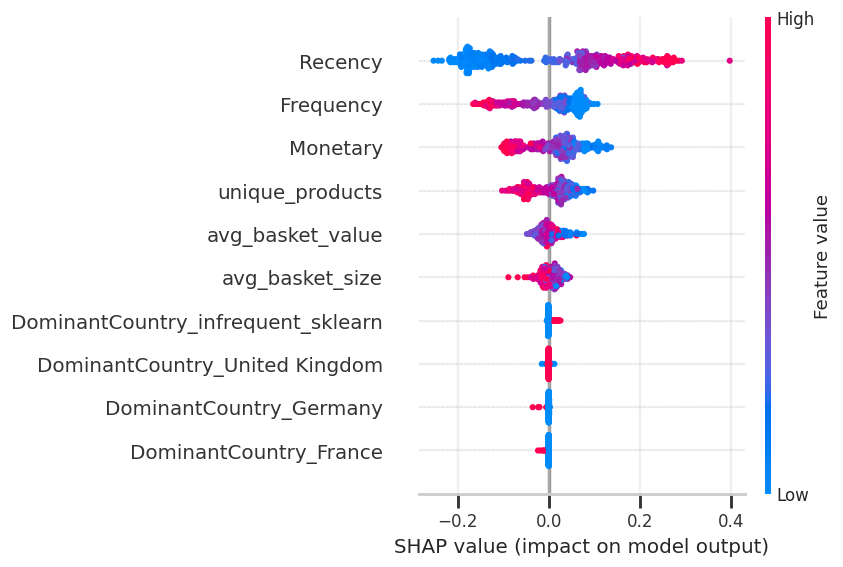

In [8]:
import shap
rf_pipeline = joblib.load(MODELS_DIR / 'RandomForest.joblib')
rf_clf = rf_pipeline.named_steps['clf']

# Sample raw test rows and transform them with the fitted leakage-safe preprocessor.
rng = np.random.default_rng(42)
idx = rng.choice(len(X_te_raw), size=min(400, len(X_te_raw)), replace=False)
X_sample_raw = X_te_raw.iloc[idx]
X_sample_s = pd.DataFrame(preprocessor.transform(X_sample_raw),
                          columns=feat_names, index=X_sample_raw.index)

explainer = shap.TreeExplainer(rf_clf)
sv = explainer.shap_values(X_sample_s)
if isinstance(sv, list):
    sv_pos = sv[1]
else:
    sv_pos = sv[..., 1] if sv.ndim == 3 else sv

plt.figure(figsize=(8, 5))
shap.summary_plot(sv_pos, X_sample_s, plot_type='bar', show=False)
plt.tight_layout(); plt.savefig('../reports/figures/05_shap_bar.png', dpi=300, bbox_inches='tight'); plt.show()

plt.figure(figsize=(8, 5))
shap.summary_plot(sv_pos, X_sample_s, show=False)
plt.tight_layout(); plt.savefig('../reports/figures/05_shap_beeswarm.png', dpi=300, bbox_inches='tight'); plt.show()

## 4b. SHAP — interpret the MLP (KernelExplainer)
Model-agnostic SHAP on the neural net, so we can compare its churn drivers against the RandomForest's and confirm they agree.

  0%|          | 0/80 [00:00<?, ?it/s]

  2%|▎         | 2/80 [00:00<00:05, 15.31it/s]

  5%|▌         | 4/80 [00:00<00:05, 15.05it/s]

  8%|▊         | 6/80 [00:00<00:04, 15.55it/s]

 10%|█         | 8/80 [00:00<00:04, 15.55it/s]

...

 92%|█████████▎| 74/80 [00:04<00:00, 16.02it/s]

 95%|█████████▌| 76/80 [00:04<00:00, 16.94it/s]

 98%|█████████▊| 78/80 [00:04<00:00, 16.70it/s]

100%|██████████| 80/80 [00:04<00:00, 16.81it/s]

100%|██████████| 80/80 [00:04<00:00, 16.42it/s]

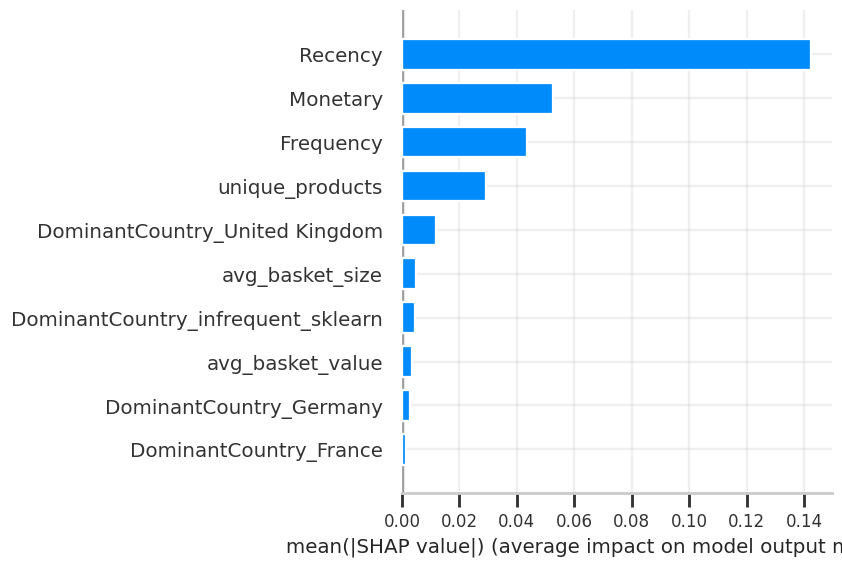

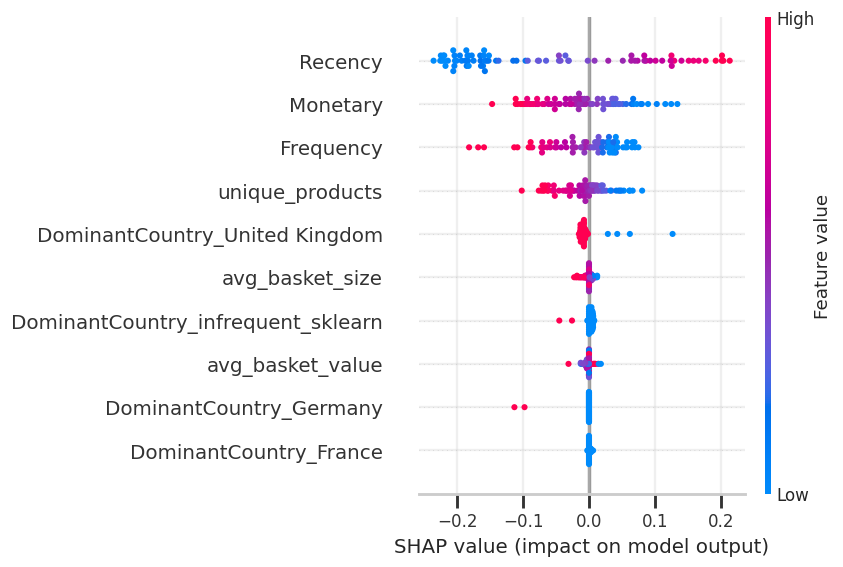

In [9]:
# SHAP on the MLP via model-agnostic KernelExplainer (small background for speed).
rng = np.random.default_rng(42)
bg_idx = rng.choice(len(X_tr), size=min(80, len(X_tr)), replace=False)
ex_idx = rng.choice(len(X_te), size=min(80, len(X_te)), replace=False)
background = np.asarray(X_tr)[bg_idx]
X_mlp_explain = np.asarray(X_te)[ex_idx]

mlp_explainer = shap.KernelExplainer(cls.mlp_proba_fn(mlp, scaler_mlp), background)
sv_mlp = mlp_explainer.shap_values(X_mlp_explain, nsamples=100)
X_mlp_df = pd.DataFrame(X_mlp_explain, columns=feat_names)

plt.figure(figsize=(8, 5))
shap.summary_plot(sv_mlp, X_mlp_df, plot_type='bar', show=False)
plt.tight_layout(); plt.savefig('../reports/figures/05_shap_mlp_bar.png', dpi=300, bbox_inches='tight'); plt.show()

plt.figure(figsize=(8, 5))
shap.summary_plot(sv_mlp, X_mlp_df, show=False)
plt.tight_layout(); plt.savefig('../reports/figures/05_shap_mlp_beeswarm.png', dpi=300, bbox_inches='tight'); plt.show()

## 5. Persist DL artifacts

In [10]:
import torch
torch.save(mlp.state_dict(), MODELS_DIR / 'mlp.pt')
torch.save(ae.state_dict(),  MODELS_DIR / 'autoencoder.pt')
joblib.dump({'mlp_scaler': scaler_mlp, 'ae_scaler': ae_scaler}, MODELS_DIR / 'dl_scalers.joblib')
anomalies.to_csv(DATA_PROCESSED / 'anomalous_customers.csv', index=False)
print('Saved MLP, AE, scalers, anomaly list.')

Saved MLP, AE, scalers, anomaly list.
